# 1.权重衰减
前面我们描述了过拟合问题，本节我们将介绍一些**正则化模型的技术**。我们总是可以通过收集更多的训练数据来缓解过拟合，但这可能成本很高，耗时更多，或者完全失去控制，因为再短期内不可能做到。 </br>
上一节中，就是多项式回归的例子中，我们呢可以通过调整拟合多项式的阶数来限制模型的容量。实际上，**限制特征的数量是缓解过拟合的一种常用技术。** 然而，简单地丢弃特征对这项工作来说过于生硬。

## 1.1 范数与权重衰减
在前面，我们描述了$L_2$范数和$L_1$范数，他们是更为一般的$L_p$范数的特例。</br>
在训练参数化机器学习模型时，**权重衰减是使用最广泛的正则化技术之一，它通常也称为$L_2$正则化。** 这项技术通过函数与零的距离来度量函数的复杂度，因为在所有函数中，函数$f=0$在某种意义上是最简单的。但是最关键的问题是：**我们该如何精确地测量一个函数和零之间的距离。**

举一个简单的例子说明为什么权重衰减可以抑制过拟合：</br>
$$
y=w_0 + w_1 x + w_2x^2+ ... + w_d x^d
$$
如果某个$w_k$非常大，那么当x稍微偏离某个区域时，$w_kx^k$依旧会对输出产生巨大影响，导致函数在训练样本点之间剧烈震荡，这种震荡往往时为了“正好穿过”每个训练点，但毫无泛化能力。

一种简单的方法是通过线性函数$f(x)=w^T x $中的权重向量的某个范数(如$||w||^2$)来度量祁复杂度。要保证权重向量较小， **最常用的方法是将其范数作为惩罚项添加到最小化损失中。将原来的训练目标最小化训练标签上的预测损失，调整为最小化预测损失和惩罚项之和。** 现在，如果权重向量增长的过大，我们的学习算法可能会更集中于最小化权重范数$||w||^2$，这正是我们想要的。

在线性回归的例子中，损失由下式给出：
$$
L(w,b) = \frac{1}{n} \sum_{i=1}^{n} \frac{1}{2}(w^Tx^{(i)} - y^{(i)})
$$
(w,b)是权重和偏置参数，为了惩罚权重向量的大小，我们必须以某种方式在损失函数中添加$||w||^2$，我们如何权衡这个额外惩罚的损失？实际上，我们通过正则化常数$\lambda$来描述这种权衡，这是一个非负超参数，我们呢使用验证数据拟合：
$$
L(w,b) + \frac{\lambda}{2}||w||^2
$$
对于$\lambda = 0$，恢复为原来的损失函数。对于$\lambda > 0$，限制$||w||$的大小。**这里我们仍然除以2，因为当去一个二次函数的导数时，2和1/2会抵消，以确保更新表达式看起来既美观又简单。** </br>
为什么这里使用平方范数而不是标准范数（即欧几里得距离）？这样做为了便于计算。通过对$L_2$范数的平方，我们去掉了平方根，留下权重向量每个分量的平方和，这使得惩罚的导数容易很容易计算，因为导数的和等于和的导数。

此外，为什么是$L_2$范数而不是$L_1$范数呢？一个原因是它对权重向量的大份量施加了巨大的惩罚，这使得我们的学习算法偏向于在大量特征上均匀分布权重的模型，在实践中，这可能会使它们对单个变量中的观测误差更为稳定。相比之下，$L_1$范
数会导致模型将权重集中在一小部分特征上，而将对其他权重清除为0，这称为**特征选择** ，可能是其他场景下所需要的。

$L_2$正则化回归与之前小批量随机梯度下降一样：
$$
w \gets (1 - \eta \lambda)w - \frac{\eta}{|B|} \sum_{i \in B} x^{(i)}(w^T x^{(i)} + b - y^{(i)})
$$
$\eta$为学习率，B为样本总量。$\lambda$是对w的约束。与特征选择相比，权重衰减为我们提供了一种连续的机制来调整函数的复杂度。

是否对相应的偏执$b^2$进行惩罚，在不同的实践中会有所不同，在神经网络的不同层中也会有所不同。通常，**网络输出层的偏执项不会被正则化。**

## 1.2 高维线性回归
通过一个简单的例子来演示权重衰减。

In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

首先我们先来收集一些数据：
$$
y = 0.05 + \sum_{i = 1}^{d}0.01x_i + \epsilon, \ \ \ 其中\epsilon ~ N(0, 0.01^2)
$$
我们选择标签是关于输入的线性函数。标签同时被均值为0且标准差为0.01的高斯噪声破坏。为了使得过拟合效果更加明显，我们可以将问题的维数增加到$d=200$，并使用一个只包含20个样本的小训练集。

In [3]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train = False)

## 1.3 从零开始
下面我们将从零开始实现权重衰减，只需将$L_2$范数的平方作为惩罚添加到原始目标函数中。
### 1. 初始化模型参数

In [12]:
def init_params():
    w = torch.normal(0, 1, size = (num_inputs, 1), requires_grad = True)
    b = torch.zeros(1, requires_grad = True)
    return[w, b]

### 2. 定义$L_2$范数惩罚

In [13]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

### 3.定义训练代码实现
从第二章依赖，线性网络和平方损失没有变化，所以我们通过d2l.linreg和d2l.squared_loss导入它们。唯一的变化是损失现在包含了惩罚项。

In [16]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss # 这里用 lambda 表达式将 w 和 b 固定到网络中。
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel = 'epochs', ylabel = 'loss', yscale = 'log', 
                            xlim = [5, num_epochs], legend = ['train', 'test'])

    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加L2范数惩罚项
            # 广播机制使L2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            # l.sum()：将批次中5个样本的损失求和，得到一个标量
            # .backward()：计算梯度，自动填充到 w.grad 和 b.grad
            d2l.sgd([w, b], lr, batch_size)
            # w = w - lr * (∇loss + 2λ·w)
            # b = b - lr * ∇loss
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss), 
                                    d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

### 4. 忽略正则化直接训练

w的L2范数是： 12.84393310546875


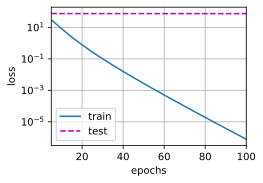

In [17]:
train(lambd = 0)

### 5. 使用权重衰减

w的L2范数是： 0.3695312440395355


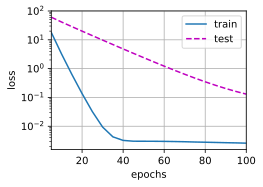

In [18]:
train(lambd = 3)

## 1.4 简洁实现
由于权重衰减在神经网络优化中很常用，因此为了便于我们使用权重衰减，深度学习框架将权重衰减集成到优化算法中，以便与任何损失函数结合使用。此外，这种集成还有计算上的好处，允许在不增加任何额外的计算开销的情况下向算法中添加权重衰减。由于更新的权重衰减部分仅依赖每个参数当前的值，因此优化器必须至少接触每个参数一次。

我们在实例化优化器时直接通过 weight_decay指定weight decay超参数。默认情况下，PyTorch同时衰减权重和偏置。这里我们只为权重设置了weight_decay,所以偏置参数b不会衰减。

In [43]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction = 'none')
    num_epochs, lr = 100, 0.003

    trainer = torch.optim.SGD([
        {"params": net[0].weight, 'weight_decay':wd},
        {"params": net[0].bias}], lr = lr)
    animator = d2l.Animator(xlabel = 'epochs', ylabel = 'loss', yscale = 'log', 
                            xlim = [5, num_epochs], legend = ['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y) 
            l.mean().backward()
            trainer.step()
            """
            trainer.step()
                执行一步优化：
                对于权重：w = w - lr * (∇loss + weight_decay * w)
                对于偏置：b = b - lr * ∇loss（无衰减）
            """
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss), 
                                    d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', net[0].weight.norm().item())

w的L2范数是： 14.285003662109375


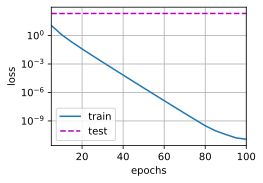

In [44]:
train_concise(0)

w的L2范数是： 0.39588233828544617


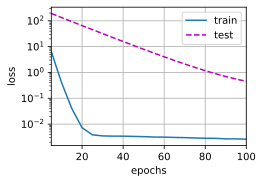

In [45]:
train_concise(3)